In [2]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent

raw_path = BASE_DIR / "data" / "raw"
processed_path = BASE_DIR / "data" / "processed"

print(raw_path)
print(processed_path)

c:\Users\ASUS\OneDrive\Desktop\bluestock-mf-capstone\data\raw
c:\Users\ASUS\OneDrive\Desktop\bluestock-mf-capstone\data\processed


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

funds = pd.read_csv(processed_path/"clean_fund_master.csv")
nav = pd.read_csv(processed_path/"02_nav_history_clean.csv")
transactions = pd.read_csv(processed_path/"clean_transactions.csv")
performance = pd.read_csv(processed_path/"clean_performance.csv")

In [8]:
print(funds.shape)
print(nav.shape)
print(transactions.shape)
print(performance.shape)

(40, 15)
(46000, 3)
(32778, 13)
(40, 19)


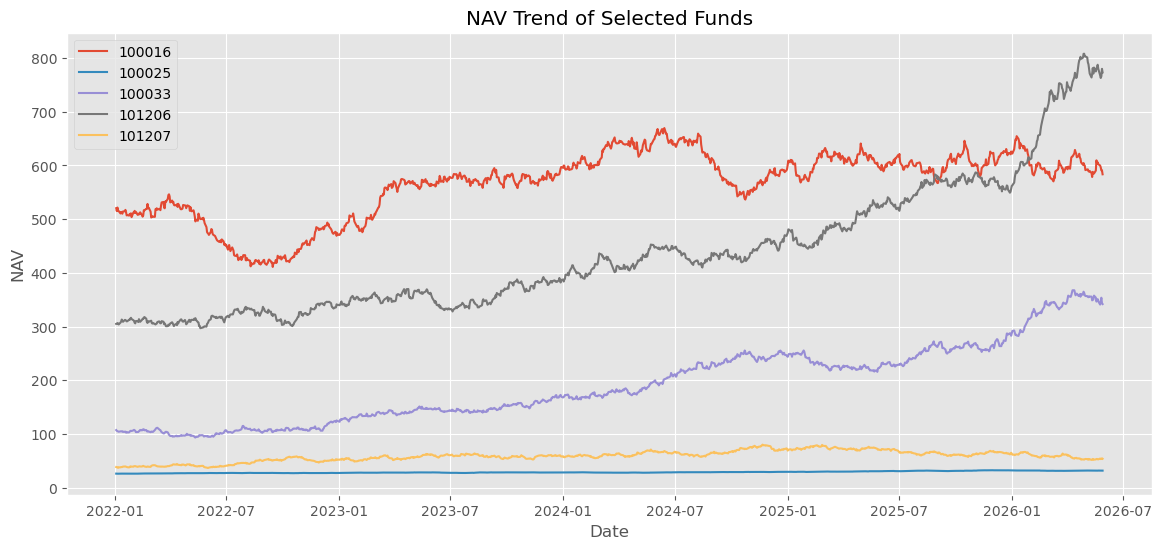

In [9]:
nav['date'] = pd.to_datetime(nav['date'])

top_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(14,6))

for code in top_funds:
    temp = nav[nav['amfi_code']==code]
    plt.plot(temp['date'], temp['nav'], label=code)

plt.title("NAV Trend of Selected Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.show()

In [12]:
transactions['age_group'].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

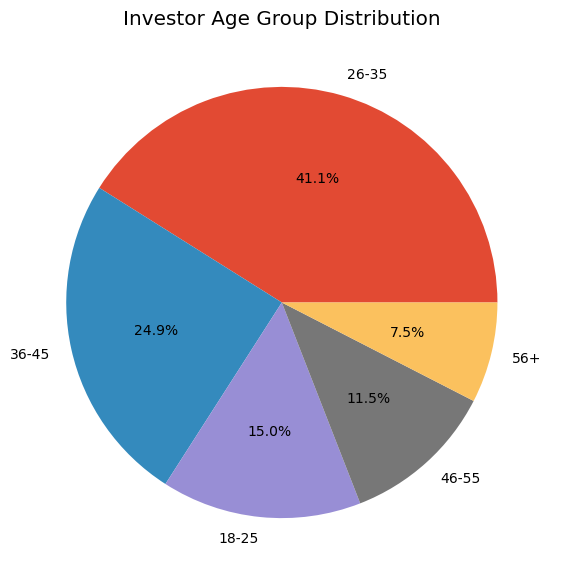

In [13]:
transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

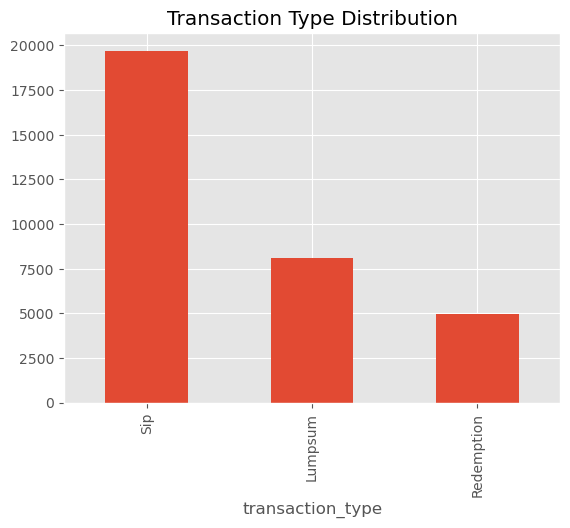

In [14]:
transactions['transaction_type'].value_counts().plot(
    kind='bar'
)

plt.title("Transaction Type Distribution")
plt.show()

In [18]:
transactions.groupby('state')['amount_inr'].sum()

state
Delhi             289633404
Gujarat           298358940
Haryana           279634354
Karnataka         273753570
Madhya Pradesh    308312493
Maharashtra       269513480
Punjab            315780459
Rajasthan         298645822
Tamil Nadu        315177237
Telangana         290219284
Uttar Pradesh     285368873
West Bengal       297182514
Name: amount_inr, dtype: int64

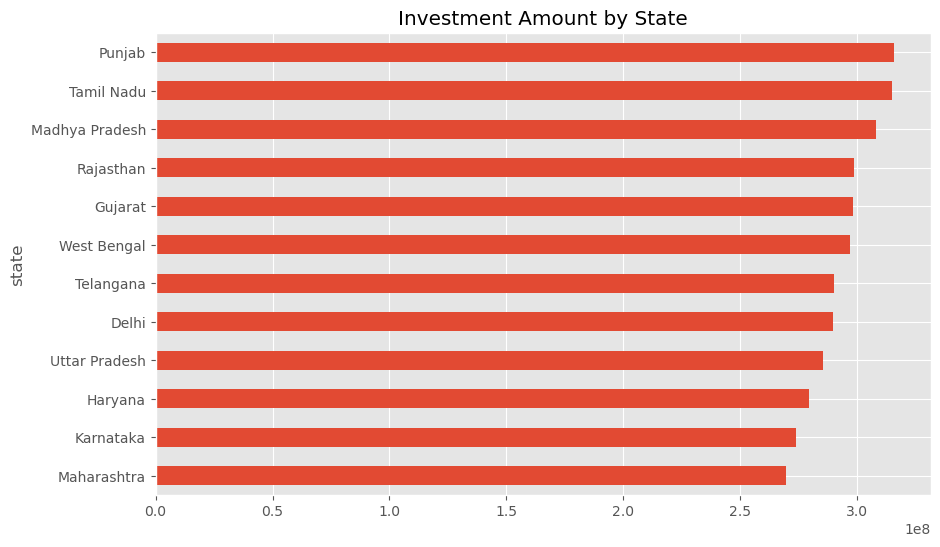

In [17]:
state_amount = transactions.groupby('state')['amount_inr'].sum()

state_amount.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Investment Amount by State")
plt.show()

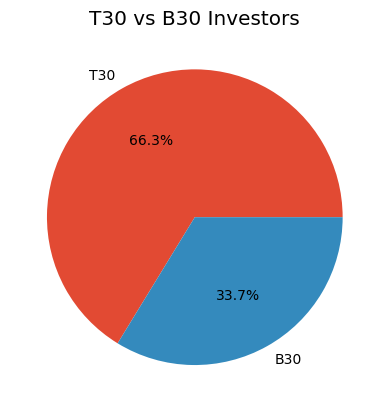

In [19]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investors")
plt.ylabel("")
plt.show()

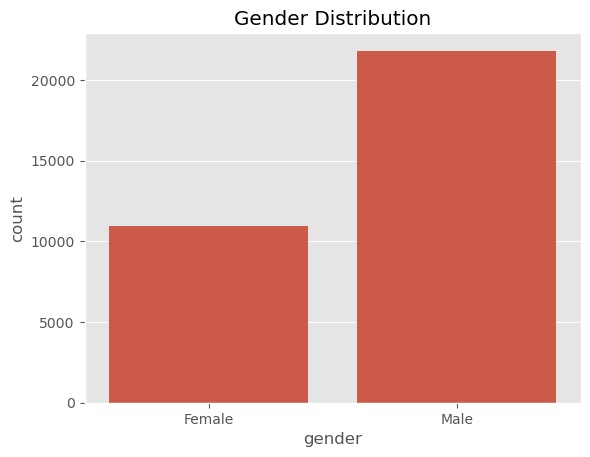

In [20]:
sns.countplot(
    data=transactions,
    x='gender'
)

plt.title("Gender Distribution")
plt.show()

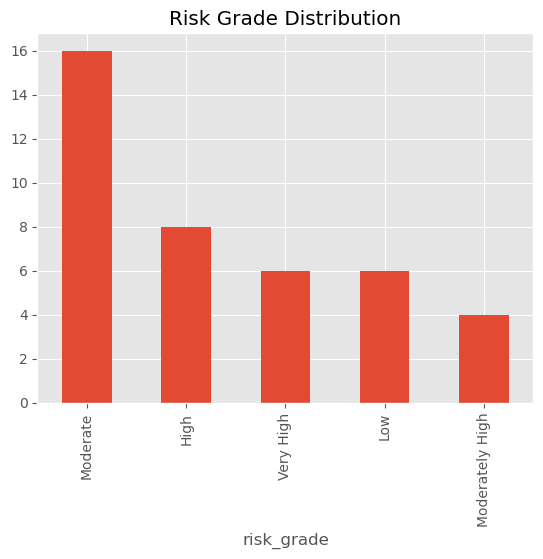

In [21]:
performance['risk_grade'].value_counts().plot(
    kind='bar'
)

plt.title("Risk Grade Distribution")
plt.show()

In [24]:
performance['sharpe_ratio'].sort_values()

39    0.80
36    0.80
26    0.80
8     0.80
1     0.81
17    0.81
32    0.82
10    0.82
27    0.84
24    0.85
25    0.87
7     0.87
20    0.87
16    0.88
0     0.88
38    0.90
29    0.90
18    0.91
35    0.91
37    0.92
31    0.93
3     0.93
2     0.94
12    0.95
6     0.96
33    0.96
21    0.96
28    0.98
13    0.98
22    0.98
15    1.00
11    1.03
5     1.06
34    1.06
19    1.33
4     1.52
9     1.84
30    5.14
23    6.18
14    7.68
Name: sharpe_ratio, dtype: float64

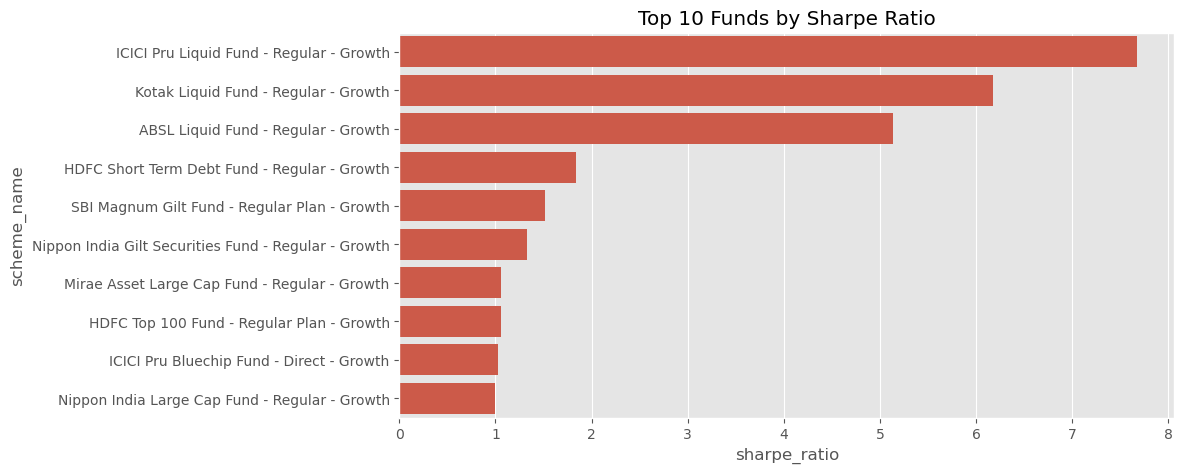

In [25]:
top_sharpe = performance.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_sharpe,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.show()

In [28]:
performance['return_3yr_pct']

0     12.36
1     11.30
2     23.39
3     23.14
4      6.07
5     14.84
6     13.38
7     16.58
8     15.29
9      7.37
10    11.54
11    14.41
12    18.08
13    14.76
14     7.68
15    14.00
16    12.33
17    20.15
18    11.77
19     5.31
20    12.25
21    18.23
22    15.65
23     6.18
24    11.84
25    12.14
26    15.18
27    20.98
28    13.78
29    22.38
30     5.14
31    12.10
32    15.61
33    15.34
34    14.81
35    14.56
36    13.58
37    12.82
38    17.16
39    20.08
Name: return_3yr_pct, dtype: float64

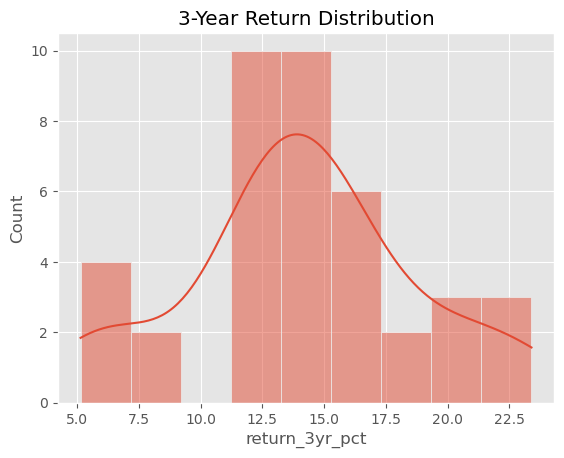

In [27]:
sns.histplot(
    performance['return_3yr_pct'],
    kde=True
)

plt.title("3-Year Return Distribution")
plt.show()

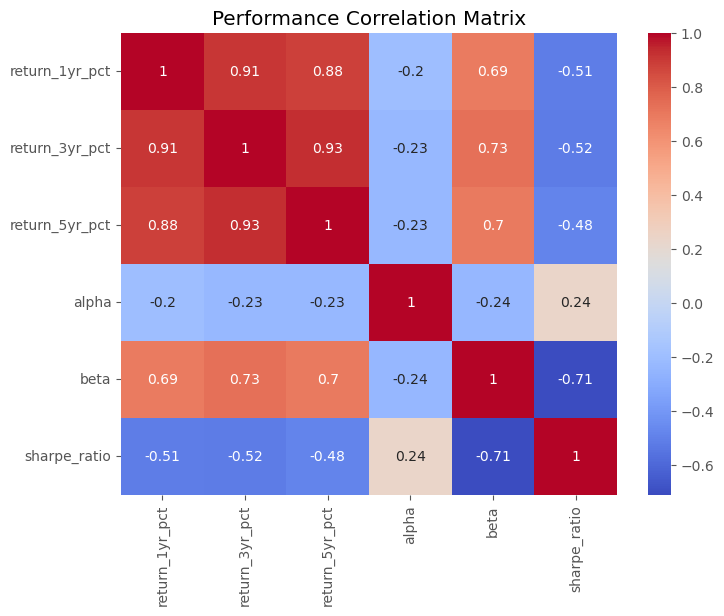

In [29]:
cols = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    performance[cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Performance Correlation Matrix")
plt.show()

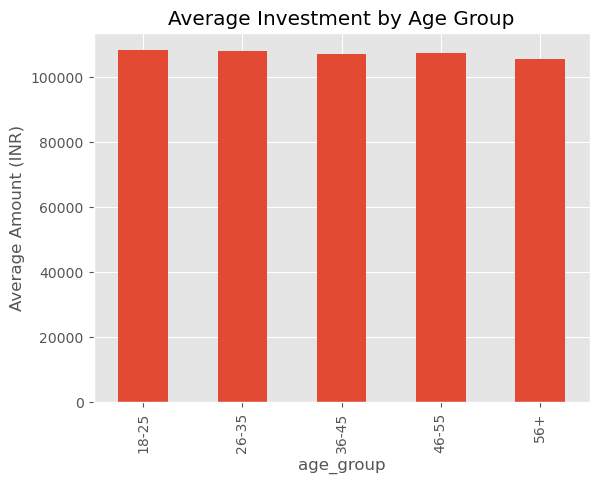

In [30]:
transactions.groupby(
    'age_group'
)['amount_inr'].mean().plot(
    kind='bar'
)

plt.title("Average Investment by Age Group")
plt.ylabel("Average Amount (INR)")
plt.show()

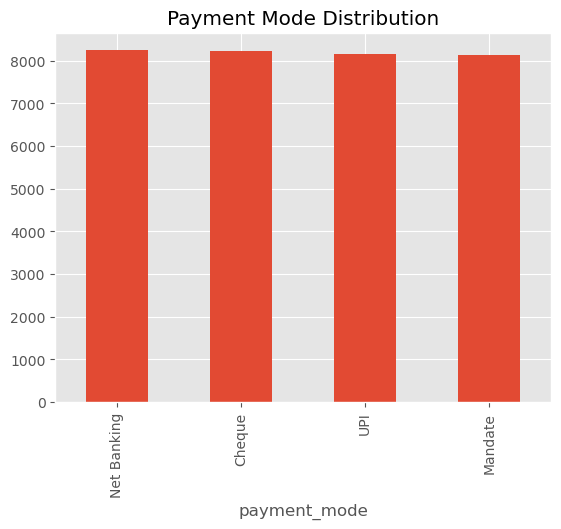

In [31]:
transactions['payment_mode'].value_counts().plot(
    kind='bar'
)

plt.title("Payment Mode Distribution")
plt.show()

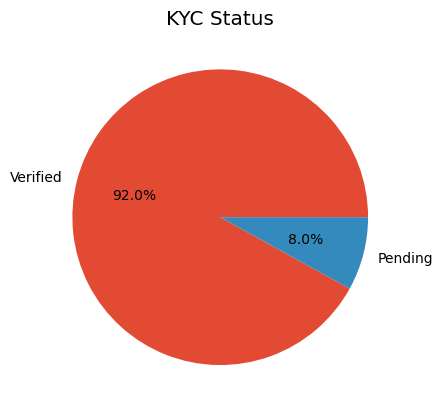

In [32]:
transactions['kyc_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("KYC Status")
plt.ylabel("")
plt.show()

# Key Findings

1. Most transactions are SIP investments.
2. Majority of investors belong to the 26–35 age group.
3. T30 cities contribute most investments.
4. UPI is the most preferred payment mode.
5. Most investors have completed KYC.
6. High-risk funds dominate the dataset.
7. Some states contribute significantly more investment volume.
8. Sharpe Ratio is positively related to fund returns.
9. Top funds show consistent NAV growth over time.
10. Younger investors are more active in mutual fund investments.